# Jupyter Notebook
# Lecture 29: Single Layer Neural Nets


<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/99/Neural_network_example.svg/1200px-Neural_network_example.svg.png" alt="Simple Neural Net" width="200"/>

In [1]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import time

# Building your own basic neural network

We're going to try to play with building some simple portions of the neural nets described in class.  

First up, let's try to build the following example we played with in class:
<img src="https://imgur.com/kO6zuGG.jpg" alt="Example Neural Net from Class" width="400"/>

&#9989; **<font color=red>Do this:</font>** Add code where noted below to create an automatic computation of the things we did in class. **Note: You can replace this code with the matrix version if you prefer, but this structure is built to work with the individual equations version.**

In [3]:
import numpy as np

def MyFirstNN(X1, X2, w, beta):
    
    A = []    
    for i in range(3): 
        z = w[i][0]*X1 + w[i][1]*X2 + w[i][2]
        Ai = np.sign(z)
        A.append(Ai)
    
    A = np.array(A)
    
    z_out = beta[0]*A[0] + beta[1]*A[1] + beta[2]*A[2] + beta[3]
    Y = np.sign(z_out)

    return Y


w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)])
print(w)

beta = np.array((-1,2,1,-2))
print('(1,0) should give  1  => ', MyFirstNN(1,0,w,beta))
print('(0,1) should give -1  => ', MyFirstNN(0,1,w,beta))

[[ 1  2  1]
 [-1  0  1]
 [ 3 -1 -1]]
(1,0) should give  1  =>  -1
(0,1) should give -1  =>  -1


&#9989; **<font color=red>Do this:</font>**  Play with the following code by changing around your $w$ and $\beta$ matrix values. 
- What sorts of changes occur in the resulting function value outputs?
- We're using the ReLU as our activation function above, which replaces the entry with the positive value of the entry.  Why am I able to get negative results out of the neural net?


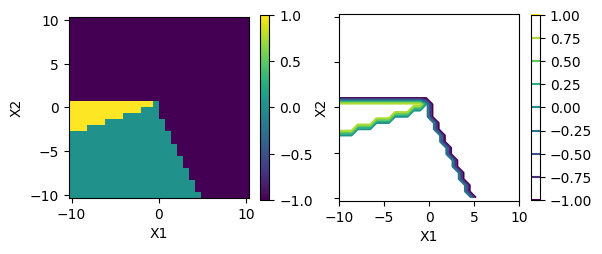

In [5]:
w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)]) #<----- Mess with these
beta = np.array((-1,2,1,-2))               #<----- These, too

#--- below here plots the output values for many combinations of 
#--- X1,X2

a = np.linspace(-10,10,30)
b = np.linspace(-10,10,30)
x,y = np.meshgrid(a,b)
M = np.zeros((len(a),len(b)))
for i in range(len(a)):
    for j in range(len(a)):
        M[i,j] = MyFirstNN(a[i],b[j],w, beta)


# --- Make plots----
fig,(ax1,ax2) = plt.subplots(1,2, sharey = True)

# Heatmap version 
ax1.set(aspect='equal')
colormesh = ax1.pcolormesh(x,y,M)
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
fig.colorbar(colormesh,ax = ax1, shrink = 0.5)

# Contour plot version 
ax2.set(aspect='equal')
contour = ax2.contour(x,y,M)
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
fig.colorbar(contour,ax = ax2, shrink = 0.5)

plt.show()


# Changing w: moves and rotates the boundary lines created by each hidden neuron, changing how the input space is divided into regions.
# Changing beta: changes how those regions are weighted and combined, affecting the final output values (including flipping signs or scaling outputs).
# Why negative outputs with ReLU? ReLU makes hidden layer outputs nonnegative, but the final output is a linear combination of those values.
# If some beta weights or the bias are negative, the final result can still be negative.

&#9989; **<font color=red>Do this:</font>** Write a modified version of your `MyFirstNN` function that uses a sigmoid function instead of ReLu. Use the block below to draw a 2D heatmap and/or contour plot like above. What sort of patterns can you get in the resulting output function? 


In [8]:
# Your code here #

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def MyFirstNN_sigmoid(X1, X2, w, beta):
    
    A = []    
    for i in range(3): 
        z = w[i][0]*X1 + w[i][1]*X2 + w[i][2]
        Ai = sigmoid(z)
        A.append(Ai)
    
    A = np.array(A)
    
    z_out = beta[0]*A[0] + beta[1]*A[1] + beta[2]*A[2] + beta[3]
    Y = z_out
    return Y

# Compared to ReLU: Smooth transitions instead of sharp edges. Sigmoid creates gradual changes, so your heatmap looks more “blurry” or continuous.
# Curved boundaries instead of straight lines. ReLU creates piecewise linear regions; sigmoid bends those into smooth curves.
# Saturation regions. Far from decision boundaries, outputs flatten because sigmoid: 0 or 1.
# Blob-like or wave-like shapes. Combining multiple sigmoids creates soft “hills,” “valleys,” or ridges.

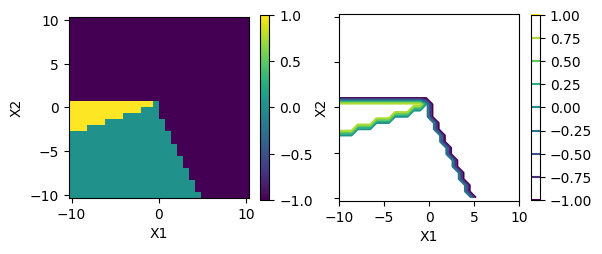

In [9]:
w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)]) #<----- Original choices 
beta = np.array((-1,2,1,-2))               #<----- of matrices

a = np.linspace(-10,10,30)
b = np.linspace(-10,10,30)
x,y = np.meshgrid(a,b)
M = np.zeros((len(a),len(b)))
for i in range(len(a)):
    for j in range(len(a)):
        M[i,j] = MyFirstNN(a[i],b[j],w, beta)
        
# --- Make plots----
fig,(ax1,ax2) = plt.subplots(1,2, sharey = True)

# Heatmap version 
ax1.set(aspect='equal')
colormesh = ax1.pcolormesh(x,y,M)
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
fig.colorbar(colormesh,ax = ax1, shrink = 0.5)

# Contour plot version 
ax2.set(aspect='equal')
contour = ax2.contour(x,y,M)
ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
fig.colorbar(contour,ax = ax2, shrink = 0.5)
plt.show()

The functions you have created are what the neural net would predict given a new input data point. 

&#9989; **<font color=red>Q:</font>** For the neural net using  $w$ and $\beta$ from class, and using the sigmoid activation function, what output prediction would you get for an input $(-10,10)$? 

In [15]:
##YOUR CODE HERE##

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def MyFirstNN_sigmoid(X1, X2, w, beta):
    
    A = []    
    for i in range(3): 
        z = w[i][0]*X1 + w[i][1]*X2 + w[i][2]
        Ai = sigmoid(z)
        A.append(Ai)
    
    A = np.array(A)
    
    Y = beta[0]*A[0] + beta[1]*A[1] + beta[2]*A[2] + beta[3]
    
    return Y


w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)])
beta = np.array((-1,2,1,-2))
print(MyFirstNN_sigmoid(-10, 10, w, beta))

# Output Prediction: -1.000016701421848

-1.000016701421848


So of course, if we were actually building this beast, our bigger job would be to find good choices of $w$ and $\beta$ based on our available training data. Let's pretend for the moment I have the following prediction data. 

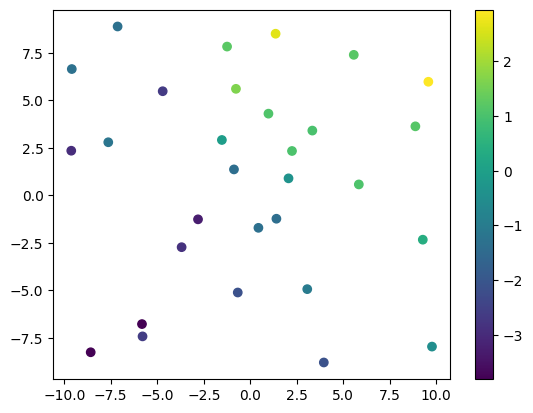

In [11]:
url ="https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/260ce1afe5ae90499a2e960020056fe9/DL-toy-data.csv"
data = np.loadtxt(url)
X = data[:,:2]
y = data[:,2]

plt.scatter(X[:,0],X[:,1], c= y)
plt.colorbar()
plt.show()

&#9989; **<font color=red>Do this:</font>** Given this particular data set, what is the mean squared error for the neural net using  $w$ and $\beta$ from class, and using the sigmoid activation function?

In [13]:
# Your code here

import numpy as np
url ="https://msu-cmse-courses.github.io/CMSE381-S26/_downloads/260ce1afe5ae90499a2e960020056fe9/DL-toy-data.csv"
data = np.loadtxt(url)
X = data[:,:2]
y = data[:,2]
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def MyFirstNN_sigmoid(X1, X2, w, beta):
    
    A = []    
    for i in range(3): 
        z = w[i][0]*X1 + w[i][1]*X2 + w[i][2]
        Ai = sigmoid(z)
        A.append(Ai)
    A = np.array(A)
    Y = beta[0]*A[0] + beta[1]*A[1] + beta[2]*A[2] + beta[3]
    return Y

w = np.array([(1,2,1),(-1,0,1),(3,-1,-1)])
beta = np.array((-1,2,1,-2))
y_pred = np.array([MyFirstNN_sigmoid(x1, x2, w, beta) for x1, x2 in X])
mse = np.mean((y_pred - y)**2)
print("Mean Squared Error:", mse)

# Mean Squared Error: 6.718148381856248

Mean Squared Error: 6.718148381856248


We're not going to train the model* ourselves, so let's switch now to the following online tool for training model. 

Open this website in another window: [https://playground.tensorflow.org](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=xor&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4&seed=0.85627&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)

*Translation: chosing better weights $w$ and $\beta$ to improve this score.


&#9989; **<font color=red>Do this:</font>** 
1. Start by working with a neural network with a single hidden layer on the data set labeled "Exclusive or". The initial setup has random weights chosen so the test loss on the right isn't very good. Hit the play button to watch the model find better and better weights to improve the prediction. 
2. Hover over the neurons on your trained model. What does the colormap shown on the right mean?
2. What does the thickness/color of the edges between features/neurons mean? How does it align with our notation from class?
2. What happens when you train the model using more or less neurons (hidden units) in the layer? What happens if you increase 
3. What happens when you train the same model on the spiral data set? 
4. If your settings are like mine, the sprial data set results are not good. Play with parameters until you can get test loss below 10\% on the spiral data set.

###YOUR ANSWER HERE###

1. What does the neuron colormap mean? The colormap shows the output value of that neuron over the input space. Different colors = different activation values. It visualizes what feature/pattern each neuron has learned (like boundaries or regions).

2. What do edge thickness and color mean? Thickness = magnitude (size) of the weight. Color = sign of the weight. Typically: one color = positive, another = negative. This directly matches class notation: These are your weights w and beta. Bigger/thicker edge → larger weight value → stronger influence

3. Effect of changing number of neurons. More neurons: Model becomes more flexible. Can learn more complex patterns. Lower training/test loss (usually). Fewer neurons: Simpler model. May underfit (can’t capture XOR well). XOR specifically needs multiple neurons (not linearly separable).

4. What happens with the spiral dataset? Much harder problem (highly nonlinear). Simple networks: Perform poorly, Struggle to capture spiral shape

5. How to get < 10% test loss on spiral. You need to increase model complexity and tune settings: More layers: 2–3 hidden layers, More neurons: 6–8 per layer (or more). Activation: tanh usually works better than ReLU here. Learning rate: about 0.01–0.03. Training longer (let it run)

With these changes, the network can “bend” decision boundaries into spiral shapes.



-----
### Congratulations, we're done!
Initially created by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh,Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.